In [1]:
from pathlib import Path
import pandas as pd, numpy as np, re, matplotlib.pyplot as plt
import os

TABLES = Path(os.environ.get("LCT_TABLES", "../results/tables"))
files = sorted(TABLES.glob("robust_*_p*.csv"))
df = pd.concat([pd.read_csv(f).assign(file=f.name) for f in files], ignore_index=True) if files else pd.DataFrame()
df.head()

,model,x_model,p,n1,n2,rho,block,cov_kind,decay,seed,...,fdr_lctb_0.05_B100,power_lctb_0.05_B100,t_lctb_0.1_B100,R_lctb_0.1_B100,V_lctb_0.1_B100,S_lctb_0.1_B100,fdr_lctb_0.1_B100,power_lctb_0.1_B100,wall_time_s,file
0,gaussian,gaussian,250,120,120,0.6,20,block_ar1,0.6,0,...,0.000000,0.110526,4.342627,21,0,21,0.000000,0.110526,1.892950,robust_gaussian_p250_covblock_ar1_n120_120_rho...
1,gaussian,gaussian,250,120,120,0.6,20,block_ar1,0.6,1,...,0.041667,0.121053,4.010206,25,2,23,0.080000,0.121053,1.727668,robust_gaussian_p250_covblock_ar1_n120_120_rho...
2,gaussian,gaussian,250,120,120,0.6,20,block_ar1,0.6,2,...,0.000000,0.100000,4.265054,20,0,20,0.000000,0.105263,1.591634,robust_gaussian_p250_covblock_ar1_n120_120_rho...
3,gaussian,gaussian,250,120,120,0.6,20,block_ar1,0.6,3,...,0.043478,0.115789,3.968770,29,4,25,0.137931,0.131579,1.900261,robust_gaussian_p250_covblock_ar1_n120_120_rho...
4,gaussian,gaussian,250,120,120,0.6,20,block_ar1,0.6,4,...,0.000000,0.110526,4.079401,23,2,21,0.086957,0.110526,1.778264,robust_gaussian_p250_covblock_ar1_n120_120_rho...


In [2]:
def collect(df, prefix, yname):
    cols = [c for c in df.columns if isinstance(c, str) and c.startswith(prefix)]
    if not cols: return pd.DataFrame()
    L = df.melt(id_vars=[c for c in df.columns if c not in cols], value_vars=cols,
                var_name="metric", value_name=yname)
    L["alpha"] = L["metric"].str.extract(r'_(0\.05|0\.10)')
    L["vm"]    = L["metric"].str.extract(r'^.*_lct_([a-z_]+)_')  # cai_liu|gaussian|jackknife
    L["method"]= np.where(L["metric"].str.contains("_bh_"), "BH",
                  np.where(L["metric"].str.contains("_by_"), "BY",
                  np.where(L["metric"].str.contains("_lctb_"), "LCT-B",
                  np.where(L["metric"].str.contains("_lct_"), "LCT-N","?"))))
    return L
pwr = pd.concat([collect(df, p, "power") for p in ["power_bh_","power_by_","power_lct_","power_lctb_"]], ignore_index=True)
fdr = pd.concat([collect(df, p, "fdr")   for p in ["fdr_bh_","fdr_by_","fdr_lct_","fdr_lctb_"]],   ignore_index=True)
agg_pwr = (pwr.groupby(["model","p","cov_kind","n1","n2","rho","alpha","method","vm"], dropna=False)["power"]
             .agg(mean="mean", se=lambda x: x.std(ddof=1)/np.sqrt(len(x))).reset_index())
agg_fdr = (fdr.groupby(["model","p","cov_kind","n1","n2","rho","alpha","method","vm"], dropna=False)["fdr"]
             .agg(mean="mean", se=lambda x: x.std(ddof=1)/np.sqrt(len(x))).reset_index())
display(agg_pwr.head()); display(agg_fdr.head())

,model,p,cov_kind,n1,n2,rho,alpha,method,vm,mean,se
0,gaussian,250,block_ar1,80,80,0.6,0.05,BH,NaN,0.053882,0.000865
1,gaussian,250,block_ar1,80,80,0.6,0.05,BY,NaN,0.027911,0.000798
2,gaussian,250,block_ar1,80,80,0.6,0.05,LCT-B,NaN,0.086628,0.000883
3,gaussian,250,block_ar1,80,80,0.6,0.05,LCT-N,cai_liu,0.097401,0.000820
4,gaussian,250,block_ar1,80,80,0.6,0.05,LCT-N,gaussian,0.095493,0.000810


,model,p,cov_kind,n1,n2,rho,alpha,method,vm,mean,se
0,gaussian,250,block_ar1,80,80,0.6,0.05,BH,NaN,0.061944,0.004473
1,gaussian,250,block_ar1,80,80,0.6,0.05,BY,NaN,0.007448,0.002139
2,gaussian,250,block_ar1,80,80,0.6,0.05,LCT-B,NaN,0.049740,0.003157
3,gaussian,250,block_ar1,80,80,0.6,0.05,LCT-N,cai_liu,0.106344,0.003816
4,gaussian,250,block_ar1,80,80,0.6,0.05,LCT-N,gaussian,0.091647,0.003751


In [3]:
# --- Show which combinations actually exist ---
print("Available block_ar1 combinations:")
print(agg_fdr[agg_fdr.cov_kind=="block_ar1"][["n1","n2","rho"]]
      .drop_duplicates().sort_values(["n1","rho"]).to_string(index=False))

# --- LCT-N FDR across sample sizes (the key result) ---
sweep = agg_fdr[(agg_fdr.cov_kind=="block_ar1") & (agg_fdr.method=="LCT-N") &
                (agg_fdr.vm=="cai_liu") & (agg_fdr.alpha=="0.05") &
                (agg_fdr.n1==agg_fdr.n2)].sort_values("n1")
print("\nLCT-N (cai_liu) FDR under block_ar1, alpha=0.05:")
print(f"{'n':>5} {'FDR':>8} {'SE':>8}")
for _, r in sweep.iterrows():
    print(f"{r.n1:>5.0f} {r['mean']:>8.3f} {r['se']:>8.4f}")
sweepB = agg_fdr[(agg_fdr.cov_kind=="block_ar1") & (agg_fdr.method=="LCT-B") &
                 (agg_fdr.alpha=="0.05") & (agg_fdr.n1==agg_fdr.n2)].sort_values("n1")
print("\nLCT-B FDR (same settings):")
for _, r in sweepB.iterrows():
    print(f"{r.n1:>5.0f} {r['mean']:>8.3f} {r['se']:>8.4f}")

Available block_ar1 combinations:
 n1  n2  rho
 80  80  0.6
 80 120  0.6
 80 200  0.6
120  80  0.6
120 120  0.6
120 200  0.6
200  80  0.6
200 120  0.6
200 200  0.6

LCT-N (cai_liu) FDR under block_ar1, alpha=0.05:
    n      FDR       SE
   80    0.106   0.0038
  120    0.062   0.0025
  200    0.054   0.0024

LCT-B FDR (same settings):
   80    0.050   0.0032
  120    0.045   0.0021
  200    0.051   0.0024


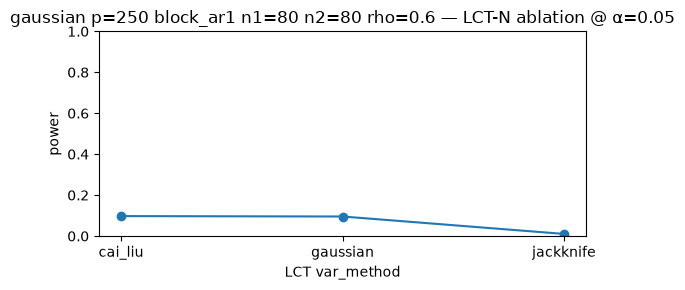

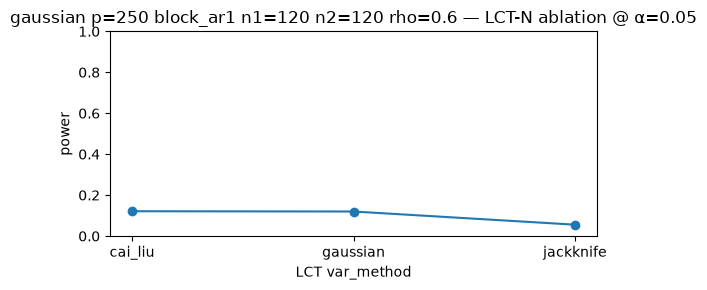

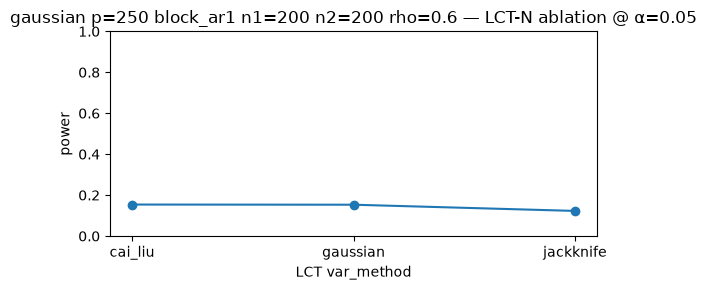

In [4]:
def plot_ablation(model, p, cov_kind, n1, n2, rho, alpha="0.05"):
    sub = agg_pwr[(agg_pwr["model"]==model)&(agg_pwr["p"]==p)&(agg_pwr["cov_kind"]==cov_kind)&
                  (agg_pwr["n1"]==n1)&(agg_pwr["n2"]==n2)&(agg_pwr["rho"]==rho)&(agg_pwr["alpha"]==alpha)]
    sub = sub[sub["method"]=="LCT-N"].copy()
    if sub.empty:
        avail = agg_pwr[(agg_pwr.model==model)&(agg_pwr.cov_kind==cov_kind)][["n1","n2","rho"]].drop_duplicates()
        print(f"no data for n1={n1}, n2={n2}, rho={rho}. Available:")
        print(avail.to_string(index=False)); return
    order = ["cai_liu","gaussian","jackknife"]
    sub["vm"] = pd.Categorical(sub["vm"], categories=order, ordered=True)
    sub = sub.sort_values("vm")
    plt.figure(figsize=(5.8,3.0))
    plt.errorbar(sub["vm"], sub["mean"], yerr=sub["se"], fmt="o-")
    plt.ylim(0,1); plt.ylabel("power"); plt.xlabel("LCT var_method")
    plt.title(f"{model} p={p} {cov_kind} n1={n1} n2={n2} rho={rho} — LCT-N ablation @ α={alpha}")
    plt.tight_layout(); plt.show()

for n in (80, 120, 200):
    plot_ablation("gaussian", 250, "block_ar1", n, n, 0.6, alpha="0.05")